In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ot

In [7]:
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # Weights of points in the source domain
b = ot.utils.unif(n2)  # Weights of points in the target domain

x1 = np.random.randn(n1, 2)  # Source points
x1 /= np.sqrt(np.sum(x1 ** 2, axis=1, keepdims=True)) / 2       # Normalize to lie on the unit circle

x2 = np.random.randn(n2, 2)  # Target points
x2 /= np.sqrt(np.sum(x2 ** 2, axis=1, keepdims=True)) / 4       # Normalize to lie on the unit circle

# # Compute the cost matrix
# C = ot.dist(x1, x2)  # Squared Euclidean cost matrix by default

### Gromov-Wasserstein and Entropic GW

The Gromov-Wasserstein distance is a similarity measure between metric measure spaces. So it does not require the samples to be in the same space

In [8]:
# Define the metric cost matrices in each spaces
C1 = ot.dist(x1, x1, metric="sqeuclidean")
C2 = ot.dist(x2, x2, metric="sqeuclidean")

C1 /= C1.max()
C2 /= C2.max()

# Solve the Gromov-Wasserstein problem
sol_gw = ot.solve_gromov(C1, C2, a=a, b=b)
P_gw = sol_gw.plan

loss_gw = sol_gw.value                      # quadratic + reg if reg > 0
loss_gw_quad = sol_gw.value_quad            # quadratic part of loss

# Solve the Entropic Gromov-Wasserstein problem
P_egw = ot.solve_gromov(C1, C2, a=a, b=b, reg=1e-2).plan

print(P_gw)
print(P_egw)

[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.02 0.   0.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.02 0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]]
[[9.39165698e-12 3.03891895e-52 4.77167432e-03 ... 6.12749440e-22
  2.62928905e-05 1.73058488e-30]
 [8.32359559e-03 1.33805687e-35 1.51676234e-12 ... 5.85117928e-38
  1.60093375e-04 5.54029809e-13]
 [3.72884173e-23 7.05153491e-52 3.45670068e-05 ... 1.97986382e-08
  2.99628127e-14 1.36342910e-39]
 ...
 [4.93936301e-36 1.01757070e-13 1.55355860e-37 ... 1.09306388e-13
  3.00702284e-40 2.47774779e-25]
 [8.40833357e-14 1.61024585e-04 1.40862908e-34 ... 3.14473552e-34
  2.46321687e-24 4.74966379e-03]
 [3.92804644e-28 6.84624937e-06 9.00317152e-41 ... 1.33991376e-24
  8.81283508e-37 2.95594318e-14]]


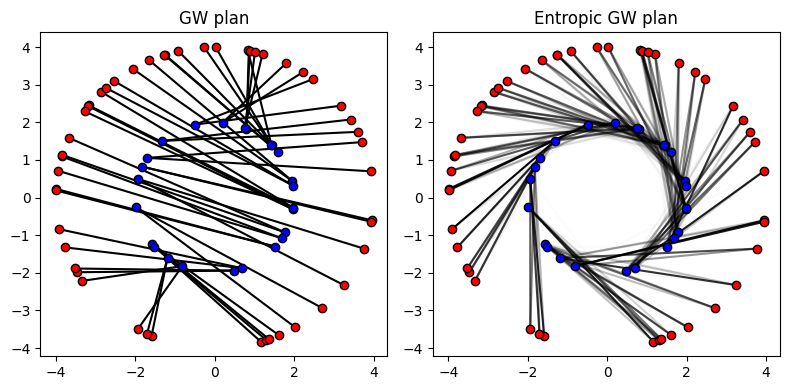

In [9]:
plt.figure(figsize=(8, 4))

# Left plot: GW plan
plt.subplot(1, 2, 1)
thresh_gw = np.max(P_gw) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_gw[i, j] > thresh_gw:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_gw[i, j] / np.max(P_gw)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('GW plan')

# Right plot: Entropic GW plan
plt.subplot(1, 2, 2)
thresh_egw = np.max(P_egw) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_egw[i, j] > thresh_egw:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_egw[i, j] / np.max(P_egw)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Entropic GW plan')

plt.tight_layout()
plt.show()

### Fused Gromov-Wasserstein

In [ ]:
# Cost matrix
M = C / np.max(C)

# Solve FGW problem with alpha=0.1
sol = ot.solve_gromov(C1, C2, M, a=a, b=b, alpha=0.1)
P_fgw = sol.plan

loss_fgw = sol.value
loss_fgw_linear = sol.value_linear  # linear part of loss (wrt M)
loss_fgw_quad = sol.value_quad  # quadratic part of loss (wrt C1 and C2)

# Solve entropic FGW problem with alpha=0.1
P_efgw = ot.solve_gromov(C1, C2, M, a=a, b=b, alpha=0.1, reg=1e-3).plan

print(P_fgw)
print(P_efgw)

[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.02]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]]
[[1.87164013e-05 8.13952561e-06 6.89810469e-04 ... 3.30960514e-03
  1.04175888e-04 3.46008634e-06]
 [1.16561591e-04 2.50796892e-07 3.02575043e-03 ... 1.70792638e-04
  9.84912667e-04 2.53840560e-06]
 [1.57255975e-05 2.91811740e-04 6.81831251e-05 ... 1.47769999e-03
  2.51438063e-05 2.62298635e-05]
 ...
 [1.09197441e-03 1.48017539e-03 5.66294267e-06 ... 1.55134419e-07
  1.57052838e-04 4.19151703e-03]
 [3.08035423e-03 3.75438370e-06 2.51462851e-04 ... 1.75893634e-07
  2.77648414e-03 2.77321817e-04]
 [2.95292603e-03 1.16825672e-04 2.49390687e-05 ... 5.81196440e-08
  7.47547271e-04 2.21779644e-03]]


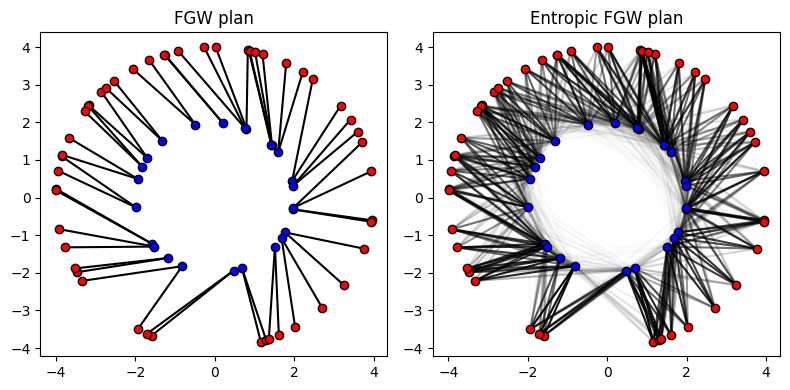

In [11]:
plt.figure(figsize=(8, 4))

# Left plot: FGW plan
plt.subplot(1, 2, 1)
thresh_fgw = np.max(P_fgw) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_fgw[i, j] > thresh_fgw:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_fgw[i, j] / np.max(P_fgw)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('FGW plan')

# Right plot: Entropic FGW plan
plt.subplot(1, 2, 2)
thresh_efgw = np.max(P_efgw) * 1e-2
for i in range(n1):
    for j in range(n2):
        if P_efgw[i, j] > thresh_efgw:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='k', alpha=min(1.0, P_efgw[i, j] / np.max(P_efgw)), zorder=0)
plt.plot(x1[:, 0], x1[:, 1], 'ob', markeredgecolor='k', markersize=6)
plt.plot(x2[:, 0], x2[:, 1], 'or', markeredgecolor='k', markersize=6)
plt.title('Entropic FGW plan')

plt.tight_layout()
plt.show()